In [1]:
# ============================================================
# Block 1 — Setup and Load Data
# ============================================================

import numpy as np
import pandas as pd
import json
import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

emb_cols = [f'emb_{i}' for i in range(32)]

print("=== Stage 2 — Classifier ===")

# ── Load features ─────────────────────────────────────────
train_features = pd.read_csv('ori_feature/train_features_v631.csv')
test_features  = pd.read_csv('ori_feature/test_features_v631.csv')

# load feature cols
with open('feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print(f"Train shape:  {train_features.shape}")
print(f"Test shape:   {test_features.shape}")
print(f"Feature cols: {len(feature_cols)}")
print(f"Fraud rate:   {train_features['isFraud'].mean():.2%}")

=== Stage 2 — Classifier ===
Train shape:  (590540, 638)
Test shape:   (506691, 637)
Feature cols: 631
Fraud rate:   3.50%


In [2]:
# load embeddings
# compare OOF vs test embedding distributions
oof_emb_df  = pd.read_csv('/workspace/Embedding_res_chain/oof_embeddings.csv', index_col=0)
test_emb_df = pd.read_csv('/workspace/Embedding_res_chain/test_embeddings_sliding_chain_5.csv', index_col=0)

print(f"OOF embeddings:  {oof_emb_df.shape}")
print(f"Test embeddings: {test_emb_df.shape}")

OOF embeddings:  (295270, 32)
Test embeddings: (506691, 32)


In [3]:
oof_stats = {
    'mean': oof_emb_df[emb_cols].mean().mean(),
    'std':  oof_emb_df[emb_cols].std().mean(),
    'max':  oof_emb_df[emb_cols].max().max(),
    'min':  oof_emb_df[emb_cols].min().min(),
}

test_stats = {
    'mean': test_emb_df[emb_cols].mean().mean(),
    'std':  test_emb_df[emb_cols].std().mean(),
    'max':  test_emb_df[emb_cols].max().max(),
    'min':  test_emb_df[emb_cols].min().min(),
}

print("OOF embeddings:", oof_stats)
print("Test embeddings:", test_stats)

# split test embeddings by chunk (which window generated them)
n_test = len(test_emb_df)
chunk_size = n_test // 10

for i in range(10):
    start = i * chunk_size
    end = (i+1) * chunk_size if i < 9 else n_test
    chunk = test_emb_df.iloc[start:end]
    print(f"Test chunk {i+1}: "
          f"mean={chunk.values.mean():.4f}, "
          f"std={chunk.values.std():.4f}")

OOF embeddings: {'mean': np.float64(0.2324504477320985), 'std': np.float64(0.49540702486180654), 'max': np.float64(62.800537), 'min': np.float64(0.0)}
Test embeddings: {'mean': np.float64(0.135743638833379), 'std': np.float64(0.2691885836959631), 'max': np.float64(71.35598), 'min': np.float64(0.0)}
Test chunk 1: mean=0.1225, std=0.3946
Test chunk 2: mean=0.1181, std=0.4371
Test chunk 3: mean=0.1284, std=0.4453
Test chunk 4: mean=0.1198, std=0.3876
Test chunk 5: mean=0.1435, std=0.4626
Test chunk 6: mean=0.1286, std=0.4144
Test chunk 7: mean=0.1470, std=0.5025
Test chunk 8: mean=0.1449, std=0.6060
Test chunk 9: mean=0.1651, std=0.6849
Test chunk 10: mean=0.1396, std=0.5077


In [4]:
# ============================================================
# Block 2 — Load Embeddings and Create Folds
# ============================================================



# sort train by time
train_sorted = train_features.sort_values('TransactionDT').reset_index(drop=True)

# create folds
n = len(train_sorted)
fold_size = n // 10
folds = {}
for i in range(10):
    start = i * fold_size
    end   = (i+1) * fold_size if i < 9 else n
    folds[i+1] = train_sorted.iloc[start:end].index.tolist()

# T6~T9 train, T10 val
T6_T9_idx = sum([folds[i] for i in range(6, 10)], [])
T10_idx   = folds[10]

# filter to rows with OOF embeddings
T6_T9_in_oof = [i for i in T6_T9_idx if i in oof_emb_df.index]
T10_in_oof   = [i for i in T10_idx   if i in oof_emb_df.index]

print(f"\nTrain (T6~T9): {len(T6_T9_in_oof):,}")
print(f"Val   (T10):   {len(T10_in_oof):,}")


Train (T6~T9): 236,216
Val   (T10):   59,054


In [5]:
# ============================================================
# Block 3 — Prepare Feature Matrices
# ============================================================

# ── Tabular features ──────────────────────────────────────
X_train_tab = train_sorted.loc[T6_T9_in_oof, feature_cols]
X_val_tab = train_sorted.loc[T10_in_oof, feature_cols]
X_test_tab = test_features[feature_cols]

# ── GCN embeddings ────────────────────────────────────────
X_train_emb = oof_emb_df.loc[T6_T9_in_oof, emb_cols].reset_index(drop=True)
X_val_emb   = oof_emb_df.loc[T10_in_oof,   emb_cols].reset_index(drop=True)
X_test_emb  = test_emb_df[emb_cols].reset_index(drop=True)

# ── Labels ────────────────────────────────────────────────
y_train = train_sorted.loc[T6_T9_in_oof, 'isFraud'].reset_index(drop=True)
y_val   = train_sorted.loc[T10_in_oof,   'isFraud'].reset_index(drop=True)

print(f"Fraud rate train: {y_train.mean():.2%}")
print(f"Fraud rate val:   {y_val.mean():.2%}")

# ── Combine tabular + embeddings ──────────────────────────
X_train = pd.concat([
    X_train_tab.reset_index(drop=True),
    X_train_emb
], axis=1)

X_val = pd.concat([
    X_val_tab.reset_index(drop=True),
    X_val_emb
], axis=1)

X_test = pd.concat([
    X_test_tab.reset_index(drop=True),
    X_test_emb
], axis=1)

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Fraud rate train: 3.62%
Fraud rate val:   3.75%

X_train: (236216, 663)
X_val:   (59054, 663)
X_test:  (506691, 663)


In [6]:
cat_fea = ['ProductCD', 'card3', 'card4', 'card5', 'card6', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_22', 'id_23', 'id_24', 'id_26', 'id_28', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'amt_decimal', 'amt_last_digit', 'D15_bin']

for col in list(cat_fea):
    tr_cats = X_train_tab[col].astype('category').cat.categories
    for df in [X_train_tab,X_val_tab,X_test,X_test_tab,X_train,X_val]:# 检查特征的方差
        df[col] = pd.Categorical(df[col], categories=tr_cats)

In [7]:
# ============================================================
# Block 4 — Baseline: Tabular Only
# ============================================================

print("=== Baseline: Tabular Only ===")

baseline_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.01, num_leaves=64,
    random_state=42, n_jobs=-1, verbosity=-1
)
baseline_model.fit(
    X_train_tab.reset_index(drop=True), y_train,
    eval_set  = [(X_val_tab.reset_index(drop=True), y_val)],
    eval_metric = 'auc',
    categorical_feature=cat_fea,
callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)


baseline_pred = baseline_model.predict_proba(
    X_val_tab.reset_index(drop=True)
)[:, 1]
baseline_auc  = roc_auc_score(y_val, baseline_pred)

print(f"\n✅ Baseline AUC (tabular only): {baseline_auc:.4f}")

=== Baseline: Tabular Only ===
[100]	valid_0's auc: 0.894136	valid_0's binary_logloss: 0.107735
[200]	valid_0's auc: 0.913052	valid_0's binary_logloss: 0.0966176
[300]	valid_0's auc: 0.926206	valid_0's binary_logloss: 0.0903708
[400]	valid_0's auc: 0.934608	valid_0's binary_logloss: 0.0864294
[500]	valid_0's auc: 0.938438	valid_0's binary_logloss: 0.0842233
[600]	valid_0's auc: 0.940495	valid_0's binary_logloss: 0.0830714
[700]	valid_0's auc: 0.940926	valid_0's binary_logloss: 0.0829372

✅ Baseline AUC (tabular only): 0.9410


In [8]:

########## filter feature for basline model 
import shap

explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_train_tab.sample(10000))

print(f"Mean abs SHAP for all feature: {abs(shap_values).mean():.4f}")

# get per-feature SHAP magnitudes
shap_per_feature = abs(shap_values).mean(axis=0)

# rank embedding features by SHAP
all_shap_df = pd.DataFrame({
    'feature': X_train_tab.columns,
    'shap':    shap_per_feature
})

all_shap_df = all_shap_df.sort_values('shap', ascending=False)

useful_cols = all_shap_df.head(400)['feature'].tolist()
X_train_tab_v2 = X_train_tab[useful_cols]
X_val_tab_v2   = X_val_tab[useful_cols]


shap_cat_fea = []
for i in cat_fea:
    if i in useful_cols:
        shap_cat_fea.append(i)


# retrain
tab_model_v2 = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.01, num_leaves=64,
    random_state=42, n_jobs=-1, verbosity=-1
)

tab_model_v2.fit(
    X_train_tab_v2, y_train,
    eval_set    = [(X_val_tab_v2, y_val)],
    eval_metric = 'auc',
    categorical_feature=shap_cat_fea,
     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

tab_pred = tab_model_v2.predict_proba(X_val_tab_v2)[:, 1]
tab_auc  = roc_auc_score(y_val, tab_pred)

print(f"\n✅ Full AUC (tabular ): {tab_auc:.4f}")


Mean abs SHAP for all feature: 0.0058
[100]	valid_0's auc: 0.893459	valid_0's binary_logloss: 0.107794
[200]	valid_0's auc: 0.912747	valid_0's binary_logloss: 0.0968349
[300]	valid_0's auc: 0.925889	valid_0's binary_logloss: 0.0905166
[400]	valid_0's auc: 0.933502	valid_0's binary_logloss: 0.0867026
[500]	valid_0's auc: 0.938017	valid_0's binary_logloss: 0.0843149
[600]	valid_0's auc: 0.940156	valid_0's binary_logloss: 0.0831587
[700]	valid_0's auc: 0.940785	valid_0's binary_logloss: 0.0828881
[800]	valid_0's auc: 0.940702	valid_0's binary_logloss: 0.0827257

✅ Full AUC (tabular ): 0.9411


In [17]:
# ── Generate submission ───────────────────────────────────
print("\n=== Generating Submission ===")

test_pred = baseline_model.predict_proba(X_test_tab)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_features['TransactionID'],
    'isFraud':       test_pred
})

submission.to_csv('/workspace/submission_tabular_half.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(f"Fraud rate pred:  {test_pred.mean():.4f}")
print(f"Min: {test_pred.min():.4f} | Max: {test_pred.max():.4f}")


=== Generating Submission ===
Submission shape: (506691, 2)
Fraud rate pred:  0.0268
Min: 0.0005 | Max: 0.9896

✅ Saved: /workspace/submission_tabular_full.csv


NameError: name 'val_auc' is not defined

In [10]:
# ============================================================
# Block 5 — Full Model: Tabular + GCN Embeddings
# ============================================================

print("=== Full Model: Tabular + GCN Embeddings ===")

full_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.01, num_leaves=64,
    random_state=42, n_jobs=-1, verbosity=-1
)

full_model.fit(
    X_train, y_train,
    eval_set    = [(X_val, y_val)],
    eval_metric = 'auc',
    categorical_feature=cat_fea,
     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

full_pred = full_model.predict_proba(X_val)[:, 1]
full_auc  = roc_auc_score(y_val, full_pred)

print(f"\n✅ Full AUC (tabular + GCN): {full_auc:.4f}")
print(f"   Baseline AUC (tabular):   {baseline_auc:.4f}")
print(f"   Improvement:              +{full_auc - baseline_auc:.4f}")

=== Full Model: Tabular + GCN Embeddings ===
[100]	valid_0's auc: 0.911563	valid_0's binary_logloss: 0.109241
[200]	valid_0's auc: 0.924369	valid_0's binary_logloss: 0.097738
[300]	valid_0's auc: 0.932906	valid_0's binary_logloss: 0.0918187
[400]	valid_0's auc: 0.938534	valid_0's binary_logloss: 0.0881729
[500]	valid_0's auc: 0.94165	valid_0's binary_logloss: 0.0861355
[600]	valid_0's auc: 0.942598	valid_0's binary_logloss: 0.0852893

✅ Full AUC (tabular + GCN): 0.9427
   Baseline AUC (tabular):   0.9410
   Improvement:              +0.0016


In [11]:
# ============================================================
# Block 6 — Feature Importance
# ============================================================

print("=== Feature Importance ===")

importance_df = pd.DataFrame({
    'feature': X_train.columns.tolist(),
    'importance': full_model.feature_importances_
}).sort_values('importance', ascending=False)

# how many embedding features in top 50?
emb_in_top50 = importance_df.head(50)['feature'].str.startswith('emb_').sum()
print(f"Embedding features in top 50: {emb_in_top50}/32")

print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))

# average importance of embeddings vs tabular
emb_imp = importance_df[importance_df['feature'].str.startswith('emb_')]['importance'].mean()
tab_imp = importance_df[~importance_df['feature'].str.startswith('emb_')]['importance'].mean()
print(f"Avg emb importance: {emb_imp:.2f}")
print(f"Avg tab importance: {tab_imp:.2f}")

=== Feature Importance ===
Embedding features in top 50: 6/32

Top 20 features:
                    feature  importance
                amt_decimal        3105
user_id1_TransactionAmt_sum         579
                      id_31         565
           user_id1_C13_max         548
                         C1         528
           user_id1_C13_sum         518
user_id1_TransactionAmt_max         493
                        C11         448
                     emb_14         438
              P_emaildomain         411
                        C14         408
                    D4_norm         389
                    D1_norm         383
user_id1_TransactionAmt_p25         380
                    D2_norm         361
                        C13         344
user_id1_TransactionAmt_p50         339
                      emb_5         332
         user_id1_dist1_min         323
                     emb_15         313
Avg emb importance: 102.22
Avg tab importance: 53.32


In [12]:
import shap

explainer = shap.TreeExplainer(full_model)
shap_values = explainer.shap_values(X_val.sample(10000))

# look at SHAP values for embedding features
emb_cols_idx = [i for i, c in enumerate(X_val.columns) if c.startswith('emb_')]
emb_shap = shap_values[:, emb_cols_idx]
print(f"Mean abs SHAP for embeddings: {abs(emb_shap).mean():.4f}")

Mean abs SHAP for embeddings: 0.0252


In [13]:
# get per-feature SHAP magnitudes
shap_per_feature = abs(shap_values).mean(axis=0)

# rank embedding features by SHAP
emb_shap_df = pd.DataFrame({
    'feature': X_val.columns,
    'shap':    shap_per_feature
})
emb_shap_df = emb_shap_df[emb_shap_df['feature'].str.startswith('emb_')]
emb_shap_df = emb_shap_df.sort_values('shap', ascending=False)
print(emb_shap_df)

#keep only top 5-10 embeddings
top_emb = emb_shap_df.head(10)['feature'].tolist()
print(f"Keeping: {top_emb}")
#top_emb = ['emb_15','emb_14' ,'emb_18', 'emb_16', 'emb_5', 'emb_2' ,'emb_1']

# rebuild X with reduced embeddings
useful_cols = feature_cols + top_emb
X_train_v2 = X_train[useful_cols]
X_val_v2   = X_val[useful_cols]
X_test_v2  = X_test[useful_cols]

# retrain
full_model_v2 = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.01, num_leaves=64,
    random_state=42, n_jobs=-1, verbosity=-1
)

full_model_v2.fit(
    X_train_v2, y_train,
    eval_set    = [(X_val_v2, y_val)],
    eval_metric = 'auc',
    categorical_feature=cat_fea,
     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

full_pred = full_model_v2.predict_proba(X_val_v2)[:, 1]
full_auc  = roc_auc_score(y_val, full_pred)

print(f"\n✅ Full AUC (tabular + GCN): {full_auc:.4f}")
print(f"   Baseline AUC (tabular):   {baseline_auc:.4f}")
print(f"   Improvement:              +{full_auc - baseline_auc:.4f}")

    feature      shap
646  emb_15  0.230195
649  emb_18  0.137564
647  emb_16  0.111765
645  emb_14  0.104521
636   emb_5  0.057373
633   emb_2  0.053065
632   emb_1  0.039550
659  emb_28  0.037909
641  emb_10  0.007514
650  emb_19  0.003778
634   emb_3  0.003120
661  emb_30  0.003088
655  emb_24  0.002234
657  emb_26  0.002045
643  emb_12  0.001959
656  emb_25  0.001667
638   emb_7  0.001529
651  emb_20  0.001518
654  emb_23  0.001355
652  emb_21  0.001137
631   emb_0  0.000869
660  emb_29  0.000556
640   emb_9  0.000350
644  emb_13  0.000312
639   emb_8  0.000302
658  emb_27  0.000161
653  emb_22  0.000018
662  emb_31  0.000007
635   emb_4  0.000003
637   emb_6  0.000000
642  emb_11  0.000000
648  emb_17  0.000000
Keeping: ['emb_15', 'emb_18', 'emb_16', 'emb_14', 'emb_5', 'emb_2', 'emb_1', 'emb_28', 'emb_10', 'emb_19']
[100]	valid_0's auc: 0.912359	valid_0's binary_logloss: 0.108308
[200]	valid_0's auc: 0.924208	valid_0's binary_logloss: 0.0968399
[300]	valid_0's auc: 0.932369	valid_


── Top 20 tabular features correlated with emb_15 ──
V258    0.463841
V52     0.454240
V257    0.445102
V51     0.443766
V79     0.439565
V58     0.433415
V57     0.428309
V15     0.421501
V50     0.420826
V16     0.420504
V72     0.417697
V39     0.414448
V94     0.413544
V40     0.413221
V93     0.412258
V71     0.411866
V92     0.411642
V246    0.411608
V42     0.410772
V17     0.409011
Name: emb_15, dtype: float64

── Top 20 tabular features correlated with emb_18 ──
V50                         0.321806
id_19_TransactionAmt_avg    0.307848
V51                         0.306877
V15                         0.305493
V16                         0.304784
id_19_TransactionAmt_p50    0.301833
V94                         0.301044
V79                         0.300793
id_20_TransactionAmt_max    0.300288
id_19_TransactionAmt_p75    0.299500
id_20_TransactionAmt_avg    0.299177
id_19_TransactionAmt_p25    0.298599
V42                         0.297756
id_20_TransactionAmt_p75    0.295030
V57  

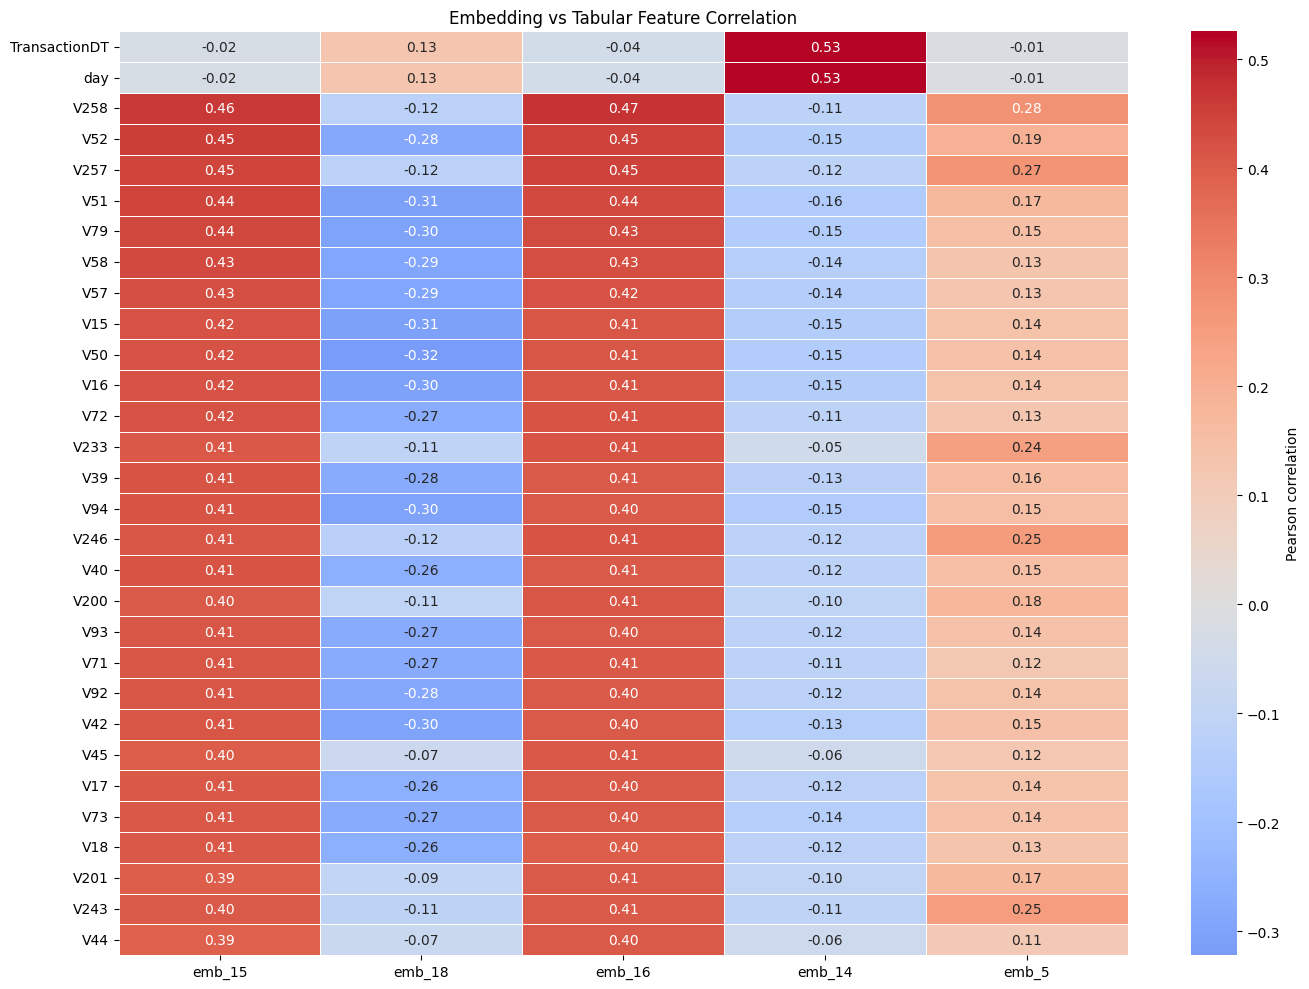

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ── your designated embeddings ──
emb_fea = ['emb_15', 'emb_18', 'emb_16', 'emb_14', 'emb_5']  # change as needed

# filter to numeric tabular features only
numeric_feature_cols = X_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# then replace feature_cols with numeric_feature_cols in the correlation



# ── compute correlation between each emb and all tabular features ──
corr_results = {}
for emb in emb_fea:
    corr = X_train[numeric_feature_cols].corrwith(X_train[emb])
    corr_results[emb] = corr

corr_df = pd.DataFrame(corr_results)  # shape: (n_tabular_features, n_emb)

# ── show top 20 most correlated tabular features for each embedding ──
for emb in emb_fea:
    print(f"\n── Top 20 tabular features correlated with {emb} ──")
    top20 = corr_df[emb].abs().sort_values(ascending=False).head(20)
    print(top20)

# ── heatmap: top 30 tabular features by max abs correlation across all emb ──
top_features = corr_df.abs().max(axis=1).sort_values(ascending=False).head(30).index
plot_df = corr_df.loc[top_features]

plt.figure(figsize=(len(emb_fea) * 2 + 4, 10))
sns.heatmap(plot_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'})
plt.title('Embedding vs Tabular Feature Correlation')
plt.tight_layout()
plt.show()

In [19]:
feature_score = pd.DataFrame({
    'feature':       X_val.columns,
    'importance':    full_model.feature_importances_,
    'shap_magnitude': abs(shap_values).mean(axis=0)
})

# normalise both to 0-1 for comparison
feature_score['imp_norm']  = feature_score['importance'] / feature_score['importance'].max()
feature_score['shap_norm'] = feature_score['shap_magnitude'] / feature_score['shap_magnitude'].max()

# combined score
feature_score['quality_score'] = feature_score['imp_norm'] * feature_score['shap_norm']
feature_score = feature_score.sort_values('quality_score', ascending=False)


# for each feature, check sign consistency
shap_signs = np.sign(shap_values)
consistency = abs(shap_signs.mean(axis=0))  
# 1.0 = always same direction, 0.0 = randomly mixed

feature_score['consistency'] = consistency

# with pd.option_context('display.max_columns', None, 'display.width', None):
#     print(feature_score.head(20))
display(feature_score.head(30))

,feature,importance,shap_magnitude,imp_norm,shap_norm,quality_score,consistency
415,amt_decimal,3105,0.115895,1.000000,0.503465,0.503465,0.1954
646,emb_15,313,0.230195,0.100805,1.000000,0.100805,0.0884
18,D1,299,0.165862,0.096296,0.720529,0.069384,0.5332
645,emb_14,438,0.104521,0.141063,0.454055,0.064050,0.8888
649,emb_18,301,0.137564,0.096940,0.597596,0.057931,0.4150
590,user_id1_C13_max,548,0.071202,0.176490,0.309310,0.054590,0.1804
579,user_id1_TransactionAmt_sum,579,0.064502,0.186473,0.280205,0.052251,0.0000
14,C11,448,0.076990,0.144283,0.334457,0.048257,0.8610
17,C14,408,0.077725,0.131401,0.337647,0.044367,0.2744
4,C1,528,0.058899,0.170048,0.255867,0.043510,0.2314


In [ ]:
# ============================================================
# Block 7 — Generate Submission
# ============================================================

print("=== Generating Submission ===")

test_pred = full_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_features['TransactionID'],
    'isFraud':       test_pred
})

submission.to_csv('/workspace/submission_embeddings_sliding_train_5.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(f"Fraud rate pred:  {test_pred.mean():.4f}")
print(f"Min:              {test_pred.min():.4f}")
print(f"Max:              {test_pred.max():.4f}")

print(f"\n{'='*50}")
print("  Final Results")
print(f"{'='*50}")
print(f"  Full AUC (tabular + GCN):   {full_auc:.4f}")
print(f"  Submission: /workspace/submission_fix_train_5csv ✅")

=== Generating Submission ===


In [5]:
import pandas as pd

base_path = '/workspace/Embedding_res_chain/'
emb_cols = ['emb_15', 'emb_14', 'emb_18', 'emb_16', 'emb_5', 'emb_2']

# ── load with sampling ──
oof_rounds = {}
for r in range(1, 6):
    df_r = pd.read_csv(f'{base_path}oof_emb_round{r}.csv', index_col=0)
    oof_rounds[r] = df_r.sample(n=min(10000, len(df_r)), random_state=42)

test_emb = pd.read_csv(f'{base_path}test_embeddings_sliding_chain_5.csv', index_col=0)
test_emb = test_emb.sample(n=min(10000, len(test_emb)), random_state=42)

# ── build table ──
frames = {}
for r in range(1, 6):
    frames[f'r{r}_mean'] = oof_rounds[r][emb_cols].mean()
    frames[f'r{r}_p50']  = oof_rounds[r][emb_cols].median()

frames['test_mean'] = test_emb[emb_cols].mean()
frames['test_p50']  = test_emb[emb_cols].median()

compare_df = pd.DataFrame(frames)

with pd.option_context('display.max_columns', None, 'display.width', None, 'display.expand_frame_repr', False):
    print(compare_df.round(4))

        r1_mean  r1_p50  r2_mean  r2_p50  r3_mean  r3_p50  r4_mean  r4_p50  r5_mean  r5_p50  test_mean  test_std  test_p50
emb_15   0.3211  0.2460   0.4435  0.4046   0.3519  0.3217   0.3019  0.2650   0.1457  0.0657     0.1457    0.1988    0.0979
emb_14   0.0000  0.0000   1.0461  1.0483   1.1976  1.2005   1.2953  1.1969   1.2320  1.0219     1.2081    1.0192    0.9843
emb_18   0.9329  0.9276   0.7561  0.6502   1.0563  1.0135   1.1507  1.0172   1.4077  0.6702     0.8405    1.0230    0.5744
emb_16   0.3242  0.2405   0.4229  0.3714   0.3339  0.2933   0.2735  0.2298   0.1525  0.0536     0.1524    0.2401    0.0932
emb_5    0.3480  0.2153   0.3886  0.2806   0.3797  0.2844   0.3296  0.1736   0.1932  0.0778     0.1807    0.2371    0.0790
emb_2    0.7587  0.6336   0.6522  0.5378   0.7133  0.5723   0.7166  0.5775   0.9360  0.3618     0.4229    0.6336    0.2626
